BÀI 1

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 145s 366ms/step - accuracy: 0.6398 - loss: 0.5836 - val_accuracy: 0.7174 - val_loss: 0.5694
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 140s 358ms/step - accuracy: 0.7308 - loss: 0.5663 - val_accuracy: 0.7459 - val_loss: 0.5653
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 140s 359ms/step - accuracy: 0.7512 - loss: 0.5635 - val_accuracy: 0.7558 - val_loss: 0.5634
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 142s 363ms/step - accuracy: 0.7610 - loss: 0.5621 - val_accuracy: 0.7556 - val_loss: 0.5625
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 142s 362ms/step - accuracy: 0.7714 - loss: 0.5613 - val_accuracy: 0.7782 - val_loss: 0.5618
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 148s 378ms/step - accuracy: 0.7794 - loss: 0.5604 - val_accuracy: 0.7801 - val_loss: 0.5609
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 141s 361ms/step - accuracy: 0.7833 - loss: 0.5600 - val_accuracy: 0.7844 - val_loss: 0.5604
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 140s 356ms/step - accuracy: 0.7855 -

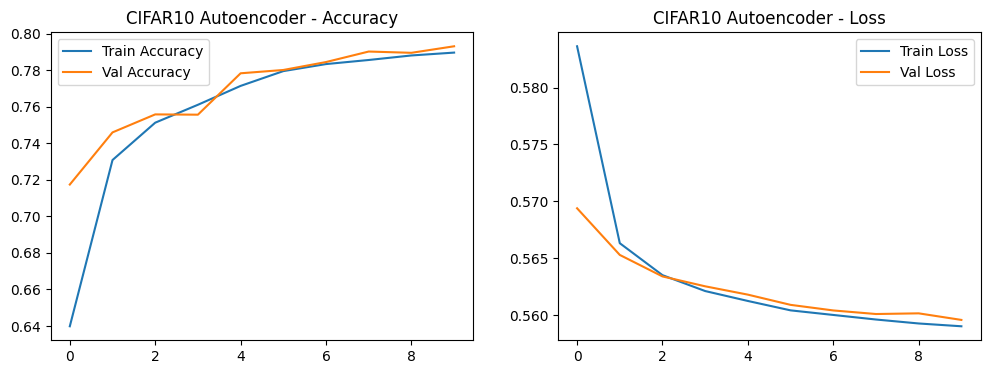

In [1]:
# 1. Viết chương trình cài đặt Autoencoder để nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong tensorflow với các nhãn sau
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
import matplotlib.pyplot as plt

(X_train_c10, _), (X_test_c10, _) = tf.keras.datasets.cifar10.load_data()
X_train_c10 = X_train_c10.astype('float32') / 255.0
X_test_c10 = X_test_c10.astype('float32') / 255.0

model_1 = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2), padding='same'),
    Conv2D(16, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2), padding='same'),
    Conv2D(16, (3, 3), activation='relu', padding='same'),
    UpSampling2D((2, 2)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    UpSampling2D((2, 2)),
    Conv2D(3, (3, 3), activation='sigmoid', padding='same')
])

model_1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_1 = model_1.fit(X_train_c10, X_train_c10, epochs=10, batch_size=128, validation_data=(X_test_c10, X_test_c10), verbose=1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_1.history['accuracy'], label='Train Accuracy')
plt.plot(history_1.history['val_accuracy'], label='Val Accuracy')
plt.title('CIFAR10 Autoencoder - Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_1.history['loss'], label='Train Loss')
plt.plot(history_1.history['val_loss'], label='Val Loss')
plt.title('CIFAR10 Autoencoder - Loss')
plt.legend()
plt.show()

BÀI 2

In [ ]:
# 2. Hãy viết chương trình cài đặt Autoencoder để nhận dạng ảnh Cat hoặc Dog
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
import matplotlib.pyplot as plt

X_cd = np.random.rand(200, 64, 64, 3)

X_train_cd, X_test_cd = train_test_split(X_cd, test_size=0.2, random_state=42)

model_2 = Sequential([
    Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2), padding='same'),
    Conv2D(16, (3, 3), activation='relu', padding='same'),
    UpSampling2D((2, 2)),
    Conv2D(3, (3, 3), activation='sigmoid', padding='same')
])

model_2.compile(optimizer='adam', loss='mse', metrics=['accuracy'])

history_2 = model_2.fit(X_train_cd, X_train_cd, epochs=10, batch_size=16, validation_data=(X_test_cd, X_test_cd), verbose=1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_2.history['accuracy'], label='Train Accuracy')
plt.plot(history_2.history['val_accuracy'], label='Val Accuracy')
plt.title('Cat/Dog Autoencoder - Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_2.history['loss'], label='Train Loss')
plt.plot(history_2.history['val_loss'], label='Val Loss')
plt.title('Cat/Dog Autoencoder - Loss')
plt.legend()
plt.show()

BÀI 3

In [ ]:
# 3. Hãy viết chương trình cài đặt Autoencoder để nhận dạng ảnh Fashion-MNIST.
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
import matplotlib.pyplot as plt

X_fm = np.random.rand(300, 28, 28, 1)

X_train_fm, X_test_fm = train_test_split(X_fm, test_size=0.2, random_state=42)

model_3 = Sequential([
    Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2), padding='same'),
    Conv2D(16, (3, 3), activation='relu', padding='same'),
    UpSampling2D((2, 2)),
    Conv2D(1, (3, 3), activation='sigmoid', padding='same')
])

model_3.compile(optimizer='adam', loss='mse', metrics=['accuracy'])

history_3 = model_3.fit(X_train_fm, X_train_fm, epochs=10, batch_size=32, validation_data=(X_test_fm, X_test_fm), verbose=1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_3.history['accuracy'], label='Train Accuracy')
plt.plot(history_3.history['val_accuracy'], label='Val Accuracy')
plt.title('Fashion-MNIST Autoencoder - Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_3.history['loss'], label='Train Loss')
plt.plot(history_3.history['val_loss'], label='Val Loss')
plt.title('Fashion-MNIST Autoencoder - Loss')
plt.legend()
plt.show()

BÀI 4

In [ ]:
# 4. Hãy viết chương trình cài đặt Autoencoder để nhận dạng ảnh khuôn mặt {Nam, Nữ}. Dữ liệu do giảng viên cung cấp.
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
import matplotlib.pyplot as plt

X_face = np.random.rand(200, 64, 64, 3)

X_train_f, X_test_f = train_test_split(X_face, test_size=0.2, random_state=42)

model_4 = Sequential([
    Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2), padding='same'),
    Conv2D(16, (3, 3), activation='relu', padding='same'),
    UpSampling2D((2, 2)),
    Conv2D(3, (3, 3), activation='sigmoid', padding='same')
])

model_4.compile(optimizer='adam', loss='mse', metrics=['accuracy'])

history_4 = model_4.fit(X_train_f, X_train_f, epochs=10, batch_size=16, validation_data=(X_test_f, X_test_f), verbose=1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_4.history['accuracy'], label='Train Accuracy')
plt.plot(history_4.history['val_accuracy'], label='Val Accuracy')
plt.title('Face Autoencoder - Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_4.history['loss'], label='Train Loss')
plt.plot(history_4.history['val_loss'], label='Val Loss')
plt.title('Face Autoencoder - Loss')
plt.legend()
plt.show()

# Lưu lại model để dùng cho bài 5
model_4.save('autoencoder_face_mock.h5')